In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Load dataset
df = pd.read_csv("../data/raw/WineQT.csv")

# Remove Id column
df.drop("Id", axis=1, inplace=True)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [2]:
# Missing values
print(df.isnull().sum())

# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Verify new shape
print("Dataset Shape:", df.shape)

# Data types
print(df.dtypes)

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
Duplicate rows: 125
Dataset Shape: (1018, 12)
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


In [3]:
# Features
X = df.drop("quality", axis=1)

# Target
y = df["quality"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1018, 11)
Target Shape: (1018,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (814, 11)
Testing Set : (204, 11)


In [5]:
standard_scaler = StandardScaler()

X_train_standard = standard_scaler.fit_transform(X_train)
X_test_standard = standard_scaler.transform(X_test)

In [6]:
minmax_scaler = MinMaxScaler()

X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

In [7]:
robust_scaler = RobustScaler()

X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust = robust_scaler.transform(X_test)

In [8]:
processed_df = pd.concat([X, y], axis=1)

processed_df.to_csv(
    "../data/processed/wine_processed.csv",
    index=False
)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


In [9]:
# Correlation of all features with quality
corr_with_quality = df.corr()["quality"].sort_values(ascending=False)

print(corr_with_quality)

quality                 1.000000
alcohol                 0.485953
sulphates               0.257519
citric acid             0.241565
fixed acidity           0.115826
residual sugar          0.022718
pH                     -0.057592
free sulfur dioxide    -0.071083
chlorides              -0.122214
total sulfur dioxide   -0.182214
density                -0.185187
volatile acidity       -0.409340
Name: quality, dtype: float64


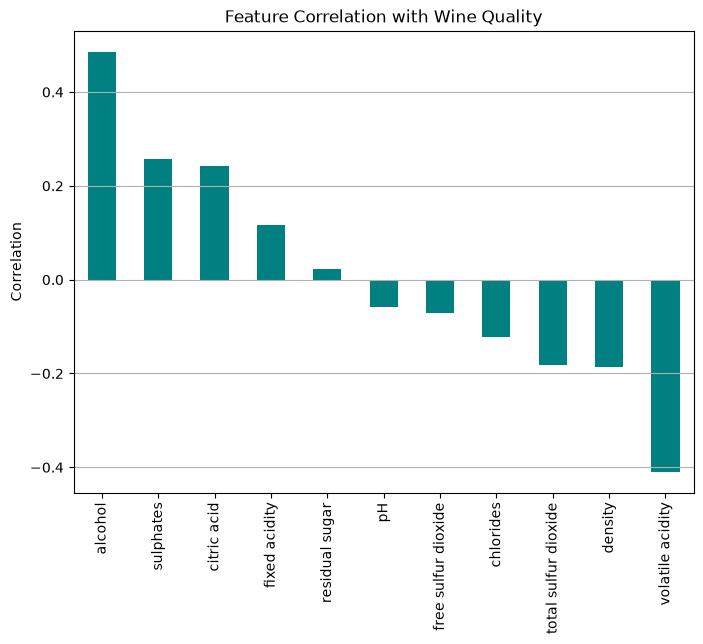

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

corr_with_quality.drop("quality").plot(kind="bar", color="teal")

plt.title("Feature Correlation with Wine Quality")
plt.ylabel("Correlation")
plt.grid(axis="y")

plt.show()

In [11]:
from sklearn.ensemble import RandomForestClassifier

# Train a temporary Random Forest model
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                 Feature  Importance
10               alcohol    0.154001
9              sulphates    0.117177
6   total sulfur dioxide    0.101317
1       volatile acidity    0.098642
7                density    0.087199
4              chlorides    0.080849
2            citric acid    0.078817
8                     pH    0.074424
0          fixed acidity    0.070513
3         residual sugar    0.070100
5    free sulfur dioxide    0.066962


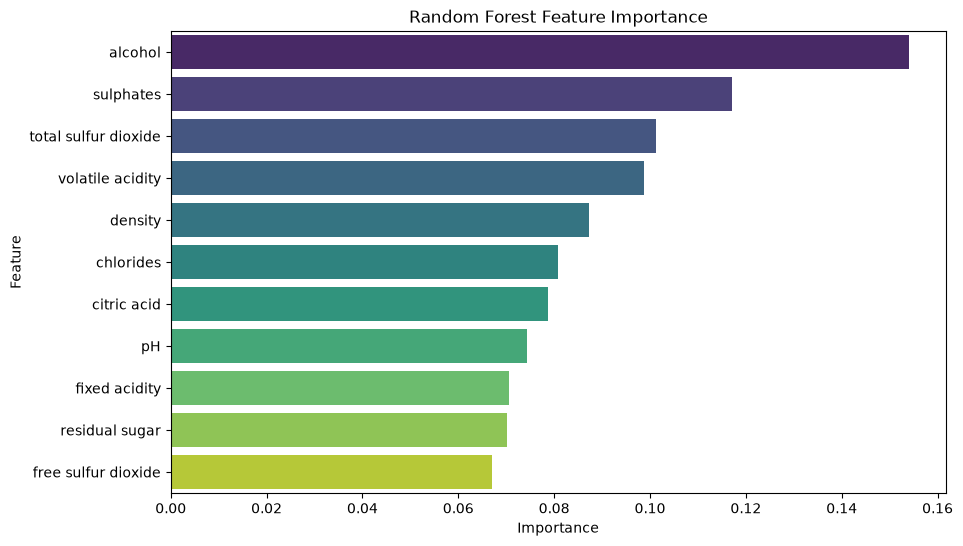

In [12]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    legend=False,
    palette="viridis"
)

plt.title("Random Forest Feature Importance")

plt.show()

In [13]:
# Display low importance features
print(
    importance[importance["Importance"] < 0.02]
)

Empty DataFrame
Columns: [Feature, Importance]
Index: []
